In [2]:
def get_weather_data(city_name, lat, lon):
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max&past_days=92&forecast_days=1&timezone=Europe/Stockholm"
    response = requests.get(url)
    data = response.json()
    
    df = pd.DataFrame({
        "date": data["daily"]["time"],
        "temp_max": data["daily"]["temperature_2m_max"],
        "temp_min": data["daily"]["temperature_2m_min"],
        "precipitation": data["daily"]["precipitation_sum"],
        "windspeed": data["daily"]["windspeed_10m_max"],
    })
    df["city"] = city_name
    df["date"] = pd.to_datetime(df["date"])
    return df

# Tüm şehirler için veri çek
all_data = []
for city, coords in cities.items():
    df = get_weather_data(city, coords["lat"], coords["lon"])
    all_data.append(df)
    print(f"✅ {city} verisi alındı - {len(df)} gün")

df_all = pd.concat(all_data, ignore_index=True)
print(f"\n📊 Toplam {len(df_all)} satır veri hazır!")
df_all.head()

✅ Göteborg verisi alındı - 93 gün
✅ Stockholm verisi alındı - 93 gün
✅ Malmö verisi alındı - 93 gün
✅ Uppsala verisi alındı - 93 gün
✅ Linköping verisi alındı - 93 gün

📊 Toplam 465 satır veri hazır!


,date,temp_max,temp_min,precipitation,windspeed,city
0,2025-12-11,NaN,NaN,NaN,NaN,Göteborg
1,2025-12-12,NaN,NaN,NaN,NaN,Göteborg
2,2025-12-13,NaN,NaN,NaN,NaN,Göteborg
3,2025-12-14,NaN,NaN,NaN,NaN,Göteborg
4,2025-12-15,NaN,NaN,NaN,NaN,Göteborg


In [3]:
# NaN satırları temizle
df_all = df_all.dropna()
df_all["temp_avg"] = (df_all["temp_max"] + df_all["temp_min"]) / 2

print(f"✅ Temiz veri: {len(df_all)} satır")
print(f"📅 Tarih aralığı: {df_all['date'].min()} → {df_all['date'].max()}")
print(f"🏙️ Şehirler: {df_all['city'].unique()}")
df_all.describe()

✅ Temiz veri: 355 satır
📅 Tarih aralığı: 2026-01-02 00:00:00 → 2026-03-13 00:00:00
🏙️ Şehirler: <StringArray>
['Göteborg', 'Stockholm', 'Malmö', 'Uppsala', 'Linköping']
Length: 5, dtype: str


,date,temp_max,temp_min,precipitation,windspeed,temp_avg
count,355,355.000000,355.000000,355.000000,355.000000,355.000000
mean,2026-02-06 00:00:00,1.190141,-3.303380,1.154930,19.525634,-1.056620
min,2026-01-02 00:00:00,-7.200000,-17.900000,0.000000,4.700000,-11.900000
25%,2026-01-19 00:00:00,-2.500000,-6.900000,0.000000,14.000000,-4.775000
50%,2026-02-06 00:00:00,0.000000,-3.200000,0.000000,18.400000,-1.900000
75%,2026-02-24 00:00:00,3.950000,0.700000,0.900000,24.100000,2.675000
max,2026-03-13 00:00:00,13.500000,6.900000,13.500000,46.800000,9.600000
std,NaN,4.929966,5.052536,2.411015,7.080816,4.797418


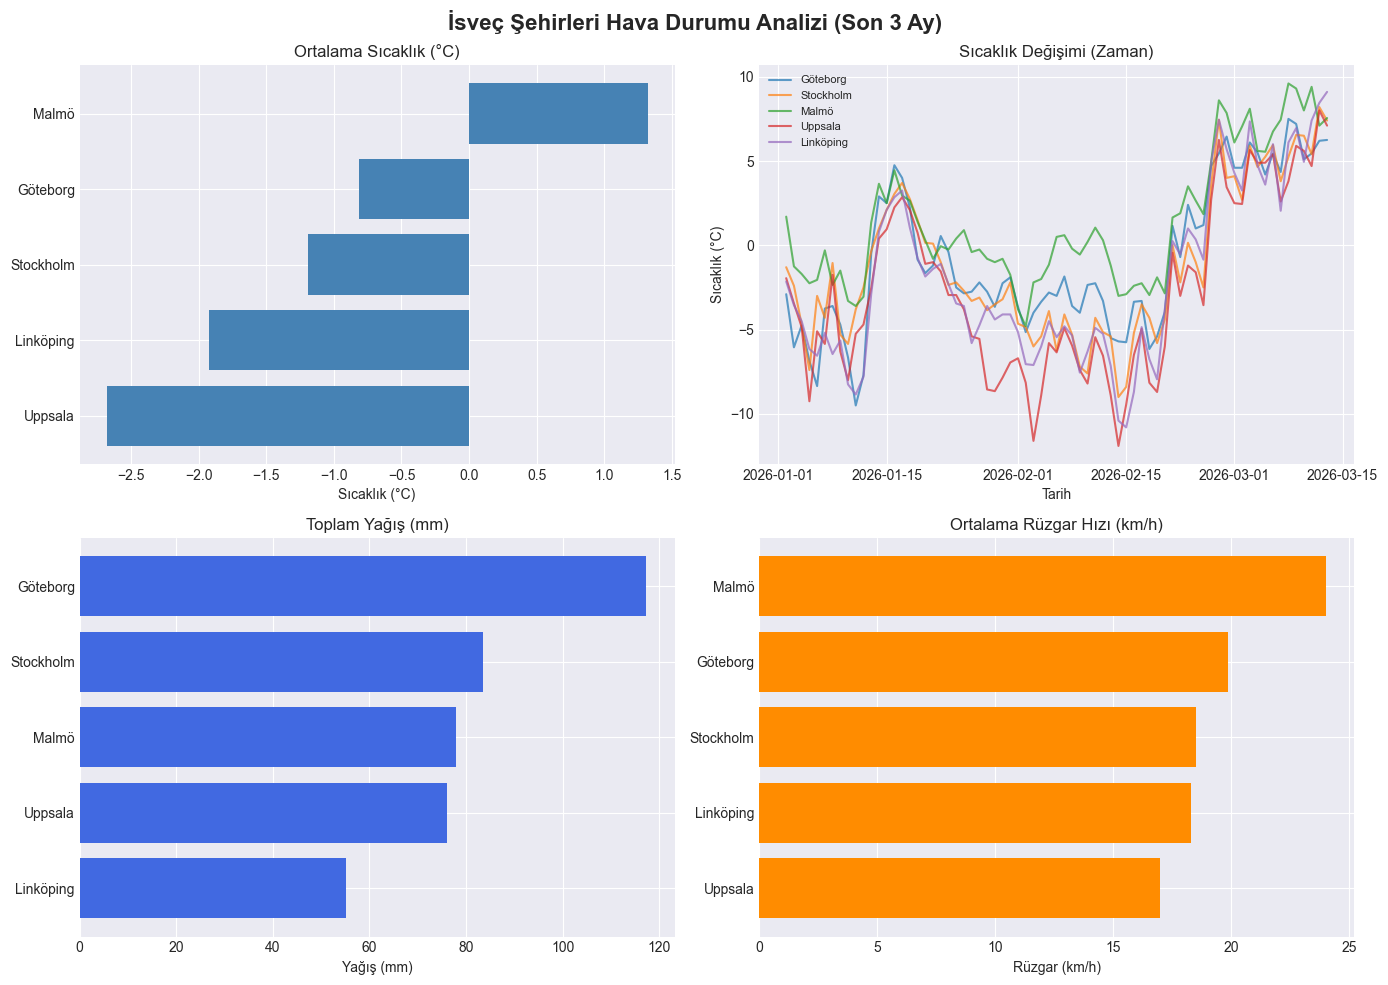

✅ Grafik kaydedildi!


In [4]:
# Grafik stilini ayarla
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("İsveç Şehirleri Hava Durumu Analizi (Son 3 Ay)", 
             fontsize=16, fontweight="bold")

# --- Grafik 1: Şehirlere göre ortalama sıcaklık ---
city_temp = df_all.groupby("city")["temp_avg"].mean().sort_values()
# groupby → şehre göre grupla, mean() → ortalamasını al

axes[0,0].barh(city_temp.index, city_temp.values, color="steelblue")
axes[0,0].set_title("Ortalama Sıcaklık (°C)")
axes[0,0].set_xlabel("Sıcaklık (°C)")

# --- Grafik 2: Zaman içinde sıcaklık değişimi ---
for city in df_all["city"].unique():
    city_data = df_all[df_all["city"] == city]
    axes[0,1].plot(city_data["date"], city_data["temp_avg"], label=city, alpha=0.7)
# alpha → saydamlık, label → legend için isim

axes[0,1].set_title("Sıcaklık Değişimi (Zaman)")
axes[0,1].legend(fontsize=8)
axes[0,1].set_xlabel("Tarih")
axes[0,1].set_ylabel("Sıcaklık (°C)")

# --- Grafik 3: Toplam yağış ---
city_rain = df_all.groupby("city")["precipitation"].sum().sort_values()
axes[1,0].barh(city_rain.index, city_rain.values, color="royalblue")
axes[1,0].set_title("Toplam Yağış (mm)")
axes[1,0].set_xlabel("Yağış (mm)")

# --- Grafik 4: Ortalama rüzgar hızı ---
city_wind = df_all.groupby("city")["windspeed"].mean().sort_values()
axes[1,1].barh(city_wind.index, city_wind.values, color="darkorange")
axes[1,1].set_title("Ortalama Rüzgar Hızı (km/h)")
axes[1,1].set_xlabel("Rüzgar (km/h)")

plt.tight_layout()
plt.savefig("sweden_weather_analysis.png", dpi=150, bbox_inches="tight")
# savefig → grafiği dosya olarak kaydet
plt.show()
print("✅ Grafik kaydedildi!")

In [5]:
# En soğuk ve en sıcak günleri bul
en_soguk = df_all.loc[df_all["temp_min"].idxmin()]
# idxmin() → en küçük değerin index numarasını verir
# loc[] → o index'teki satırın tamamını getirir

en_sicak = df_all.loc[df_all["temp_max"].idxmax()]
# idxmax() → en büyük değerin index numarasını verir

en_ruzgarli = df_all.loc[df_all["windspeed"].idxmax()]
en_yagisli = df_all.loc[df_all["precipitation"].idxmax()]

print("🥶 En Soğuk Gün:")
print(f"   {en_soguk['city']} - {en_soguk['date'].date()} → {en_soguk['temp_min']}°C")

print("\n☀️ En Sıcak Gün:")
print(f"   {en_sicak['city']} - {en_sicak['date'].date()} → {en_sicak['temp_max']}°C")

print("\n💨 En Rüzgarlı Gün:")
print(f"   {en_ruzgarli['city']} - {en_ruzgarli['date'].date()} → {en_ruzgarli['windspeed']} km/h")

print("\n🌧️ En Yağışlı Gün:")
print(f"   {en_yagisli['city']} - {en_yagisli['date'].date()} → {en_yagisli['precipitation']} mm")

🥶 En Soğuk Gün:
   Linköping - 2026-02-15 → -17.9°C

☀️ En Sıcak Gün:
   Malmö - 2026-03-08 → 13.5°C

💨 En Rüzgarlı Gün:
   Göteborg - 2026-03-13 → 46.8 km/h

🌧️ En Yağışlı Gün:
   Stockholm - 2026-01-14 → 13.5 mm
